combining grav_modeling_2options and 4lay

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [21]:
df = pd.read_csv('..\\..\\created_data\\lola_grav_age_q_z_bath.csv', header=0)

print(df.head())

         long        lat         FA        age  q_ihfc       q_ps    q_stein  \
0 -133.000003  37.983334 -20.522749  33.939312    19.0  81.209931  87.542442   
1 -133.000003  38.100001 -24.824638  33.939312    19.0  81.209931  87.542442   
2 -133.000003  38.216667 -31.192137  33.939312    19.0  81.209931  87.542442   
3 -133.000003  38.333334 -38.186611  33.939312    19.0  81.209931  87.542442   
4 -133.000003  38.450001 -32.169643  33.939312    19.0  81.209931  87.542442   

          ps_z        stein_z   bathy  
0  4539.010966  423035.068147 -5025.0  
1  4539.010966  423035.068147 -5037.0  
2  4539.010966  423035.068147 -5054.0  
3  4539.010966  423035.068147 -5046.0  
4  4539.010966  423035.068147 -4910.0  


In [22]:
x = df.drop(columns=['FA', 'age', 'q_ihfc', 'q_ps', 'q_stein', 'stein_z', 'bathy'])

adding .values[0] so the series will pull out a scalar 

and also took away double brackets as that creates a dataframe instead of a series, which uses single brackets

In [23]:
# trim_ps_z = {}
# for lat in df['lat'].unique():
#     trim_ps_z[lat] = df[df['lat'] == lat]['ps_z'].values

In [24]:
rho1 = 500
r1 = 20
z1 = 2350

v1 = 4 / 3 * np.pi * r1**3

L = df['long'].max() - df['long'].min()
dL = 1
s1 = 2

G = 6.674 * 1e-11  # grav constant
dx = np.arange(0, L, dL)  # matrix of survey
x1 = dx - s1

n1 = (x1**2 + z1**2)**1.5
g1 = G * rho1 * v1 * z1 / n1 * 1e5

x['lat'] == lat: boolean to check if lat is true/false to specified lat

x[...] only selects true rows

.reset_index(drop=True) replaces index labels

atol = +- of lat hence the .5 lat

In [25]:
lat = 50.5

profile = x[np.isclose(x['lat'], lat, atol= 0.5)].sort_values('long').reset_index(drop=True)

In [26]:
print(profile)

            long        lat         ps_z
0    -133.000003  50.000001  3451.353059
1    -133.000003  50.116668  3451.353059
2    -133.000003  50.233334  3451.353059
3    -133.000003  50.350001  3451.353059
4    -133.000003  50.466668  3451.353059
...          ...        ...          ...
1084 -119.000003  50.466668  3566.491478
1085 -119.000003  50.583334  3566.491478
1086 -119.000003  50.700001  3566.491478
1087 -119.000003  50.816668  3549.666829
1088 -119.000003  50.933334  3549.666829

[1089 rows x 3 columns]


In [27]:
width = profile['long'].diff().mean()

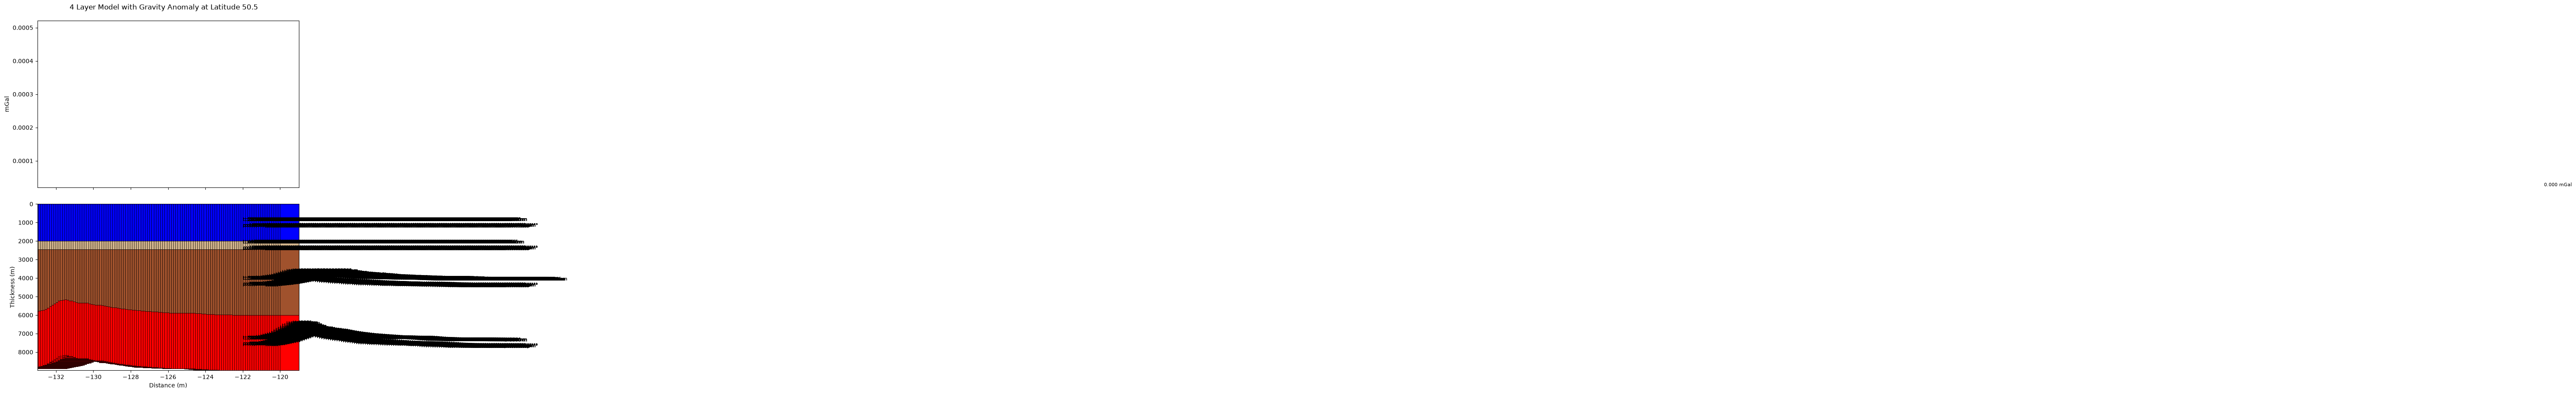

In [28]:
fig, (ax0, ax1) = plt.subplots(2,1, figsize=(8, 10), sharex=True)

ax0.plot(dx, g1, color='black', label='Gravitational Anomaly', linewidth=1)
ax0.scatter(dx[np.argmax(g1)], g1[np.argmax(g1)], color='red', edgecolors='red', marker='*', s=50, label='Max Anomaly')
ax0.text(dx[np.argmax(g1)], g1[np.argmax(g1)], f'{g1[np.argmax(g1)]:.3f} mGal', fontsize=8, va='bottom', ha='center')

ax0.set_ylim(np.min(g1), np.max(g1) + 0.0005)
ax0.set_ylabel('mGal')

width = 2  # width for each column

for i, row in profile.iterrows():
    long = row['long']
    crust_thick = row['ps_z']   # this is what varies per longitude

    x0 = long - width / 2
    x1 = long + width / 2


    layers = {
    'water': {'thickness': 2000, 'density': 1030, 'color': 'blue'},
    'sediment': {'thickness': 445,  'density': 1880, 'color': 'tan'},
    'crust': {'thickness': crust_thick, 'density': 2750, 'color': 'sienna'},
    'mantle': {'thickness': 3000,'density': 3200, 'color': 'red'}}

    bottom = 0
    polys = {}

    
    # name is key, l is value
    for name, l in layers.items():
        # print(f'name: {name}\n l: {l}')
        n = l['thickness']
        rho_l = l['density']
        top = bottom + n

        #bl, br, tl, tr
        verts = [(x0, bottom), (x1, bottom),
            (x1, top), (x0, top)]

        poly = Polygon(verts, closed=True, facecolor=l['color'], edgecolor='black', linewidth=0.5)
        ax1.add_patch(poly)

        ax1.text(x0 + (x1 - x0) + 10, bottom + n/2, f't: {n} m\nρ: {rho_l} kg/m³', 
                va='center', ha='left', fontsize=8)

        # stores the polygon under its layer name in the dict 
        polys[name] = poly

        bottom += n

# loc of sphere vs depth
# ax1.scatter(s1, z1, color='indigo', marker='o', s=r1, label='Buried Sphere 1', edgecolors='black')
# ax1.text(s1, z1 + r1 + 400, f'r: {r1} m\nρ: {rho1} kg/m³', fontsize=8, va='top', ha='center')


ax1.set_xlim(profile['long'].min(), profile['long'].max())
ax1.set_ylim(0, bottom)
ax1.set_ylabel('Thickness (m)')
ax1.set_xlabel('Distance (m)')
ax1.invert_yaxis()

# leg = ax1.legend(loc='lower left', fontsize=10)
# for handle in leg.legend_handles:
#     handle.set_sizes([50])

fig.suptitle(f'4 Layer Model with Gravity Anomaly at Latitude {lat}', fontsize=12)
fig.subplots_adjust(top=0.94, hspace=0.1)

plt.savefig(f'..\\..\\figures\\4lay\\lat{lat}ps_z_4laymod.png', dpi=400, bbox_inches='tight')
plt.show()

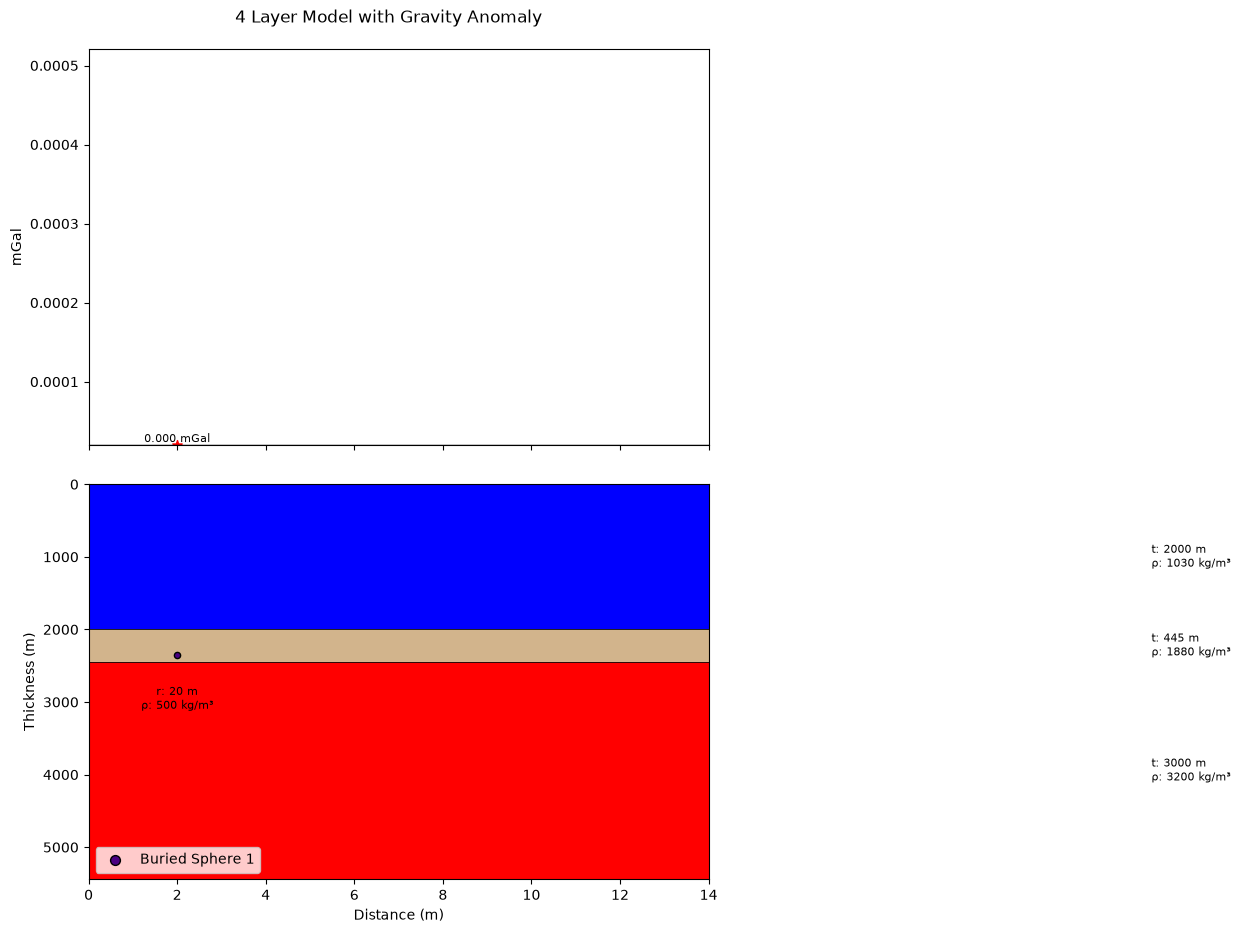

In [50]:
fig, (ax0, ax1) = plt.subplots(2,1, figsize=(8, 10), sharex=True)

ax0.plot(dx, g1, color='black', label='Gravitational Anomaly', linewidth=1)
ax0.scatter(dx[np.argmax(g1)], g1[np.argmax(g1)], color='red', edgecolors='red', marker='*', s=50, label='Max Anomaly')
ax0.text(dx[np.argmax(g1)], g1[np.argmax(g1)], f'{g1[np.argmax(g1)]:.3f} mGal', fontsize=8, va='bottom', ha='center')

ax0.set_ylim(np.min(g1), np.max(g1) + 0.0005)
ax0.set_ylabel('mGal')

# defining poly geom
x0 = df['long'].min()
x1 = L
bottom = 0

polys = {}

# name is key, l is value
for name, l in layers.items():
    # print(f'name: {name}\n l: {l}')
    n = l['thickness']
    rho_l = l['density']
    top = bottom + n

    #bl, br, tl, tr
    verts = [(x0, bottom), (x1, bottom),
        (x1, top), (x0, top)]

    poly = Polygon(verts, closed=True, facecolor=l['color'], edgecolor='black', linewidth=0.5)
    ax1.add_patch(poly)

    ax1.text(x0 + (x1 - x0) + 10, bottom + n/2, f't: {n} m\nρ: {rho_l} kg/m³', 
             va='center', ha='left', fontsize=8)

    # stores the polygon under its layer name in the dict 
    polys[name] = poly

    bottom += n

# loc of sphere vs depth
ax1.scatter(s1, z1, color='indigo', marker='o', s=r1, label='Buried Sphere 1', edgecolors='black')
ax1.text(s1, z1 + r1 + 400, f'r: {r1} m\nρ: {rho1} kg/m³', fontsize=8, va='top', ha='center')


ax1.set_xlim(0, x1)
ax1.set_ylim(0, bottom)
ax1.set_ylabel('Thickness (m)')
ax1.set_xlabel('Distance (m)')
ax1.invert_yaxis()

leg = ax1.legend(loc='lower left', fontsize=10)
for handle in leg.legend_handles:
    handle.set_sizes([50])

fig.suptitle('4 Layer Model with Gravity Anomaly', fontsize=12)
fig.subplots_adjust(top=0.94, hspace=0.1)

plt.savefig('..\\..\\figures\\4lay\\FA_4laymod.png', dpi=400, bbox_inches='tight')
plt.show()